In [6]:
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

In [7]:
def convert_price_to_float(price):
    # Remove currency symbols and commas, and then convert to float
    price = re.sub(r'[^\d.]', '', price)  # Remove non-digit characters except '.'
    return float(price) if price else 0.0

In [8]:
def get_snapdeal_products(search_query):
    url = f'https://www.snapdeal.com/search?keyword={search_query.replace(" ", "%20")}'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/98.0.4758.102 Safari/537.36'
    }

    response = requests.get(url, headers=headers)
    products_data = []

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')
        products = soup.find_all('div', {'class': 'product-tuple-listing'})

        for product in products:
            title = product.find('p', {'class': 'product-title'})
            price = product.find('span', {'class': 'product-price'})
            if price:
                product_price = convert_price_to_float(price.get('data-price', '0'))
            else:
                product_price = 0.0  # Default to 0 if no price found
            rating = product.find('div', {'class': 'filled-stars'})  # Assuming rating is shown with this class

            if title and price:
                product_name = title.text.strip()
                #product_price = re.sub(r'[^\d.]', '', price.text.strip())  # Remove non-numeric chars for price
                product_rating = rating['style'].split(';')[0].split(':')[-1] if rating else "No rating"
                products_data.append({
                    'Product': product_name,
                    'Price': float(product_price),
                    'Rating': product_rating
                })
                print(f'Product: {product_name}')
                print(f'Price: {product_price}')
                print(f'Rating: {product_rating}')
                print('---')

    else:
        print('Failed to retrieve content')

    return products_data

In [9]:
search_query = input('Enter product to search on Amazon: ')
products = get_snapdeal_products(search_query)

Enter product to search on Amazon:  bottle


Product: (Pack 1) Cartoon water bottle for kids, Kawaii Water Bottle, School Water bottle for kids, Girls Water Bottle, Designed Water bottle for Girls, kids school water bottle, Cartoon Water Bottle, Kawaii Water Bottle for Girls (Multicolor)
Price: 292.0
Rating: 100.0%
---
Product: Meghal BPA Free Reusabl leak proof Deer Horn Design Water Bottle For Kids
Price: 184.0
Rating: 100.0%
---
Product: 1300ml Fruit Infuser Detox Ice Cream Theme Sipper Bottle, BPA-Free Stylish Water Bottle, Fruit Detox Bottle for Girls,Kids Water Bottle | Multi Colour
Price: 285.0
Rating: 100.0%
---
Product: 500ml Stainless Steel Black Vacuum Insulated Thermos Flask Water Bottle with 3 Tea Cups Set with Gift Box
Price: 469.0
Rating: 80.0%
---
Product: SHB Double Wall Vacuum Insulated Stainless Steel Hot and Cold Water Bottle,Travel Thermos Flask,500 ml (Silver)
Price: 452.0
Rating: 74.0%
---
Product: Purple Dust BPA Free Reusable leak proof Deer Horn Design Water Bottle For Kids
Price: 198.0
Rating: 76.0%
---

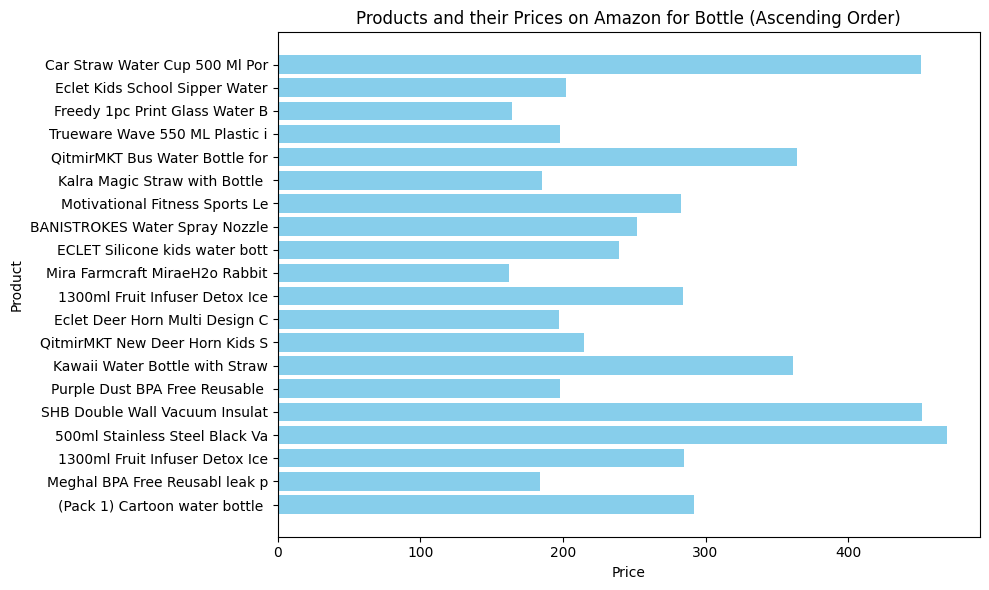

In [10]:
# Displaying product data using a bar chart
if products:  # Check if products list is not empty
    product_names = [product['Product'][:30] if len(product['Product']) > 30 else product['Product'] for product in products]
    product_prices = [product['Price'] for product in products]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(product_prices)), product_prices, color='skyblue')
    plt.xlabel('Price')
    plt.ylabel('Product')
    plt.title(f'Products and their Prices on Amazon for {search_query.capitalize()} (Ascending Order)')
    plt.yticks(range(len(product_prices)), product_names)  # Setting y-axis labels as shortened product names
    plt.tight_layout()
    plt.show()
else:
    print('No products found.')